<a href="https://colab.research.google.com/github/daniivelascoo/ifp-programacion-ia/blob/main/Teoria_2_2_C_Overfitting_Visual_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Teoría Bloque C: Ricitos de Oro (Underfitting vs Overfitting)
**Sprint 2.2 - Algoritmos de Machine Learning**

En IA, buscamos el equilibrio perfecto.
*   Si el modelo es muy simple, no aprende (**Underfitting**).
*   Si el modelo es muy complejo, memoriza el ruido y no sirve para datos nuevos (**Overfitting**).

Hoy vamos a visualizar este fenómeno usando un **Árbol de Decisión** para predecir una curva.

### 🎯 Objetivos:
1.  **Complejidad:** Controlar la "inteligencia" del modelo (`max_depth`).
2.  **Visualización:** Ver la diferencia entre aprender el patrón y memorizar el ruido.

## 1. El Problema: Una Señal con Ruido

Vamos a simular datos de un sensor. La señal real es una **Curva (Seno)**, pero el sensor tiene interferencias (Ruido aleatorio).
La IA debe aprender la curva suave, ignorando los saltos aleatorios.

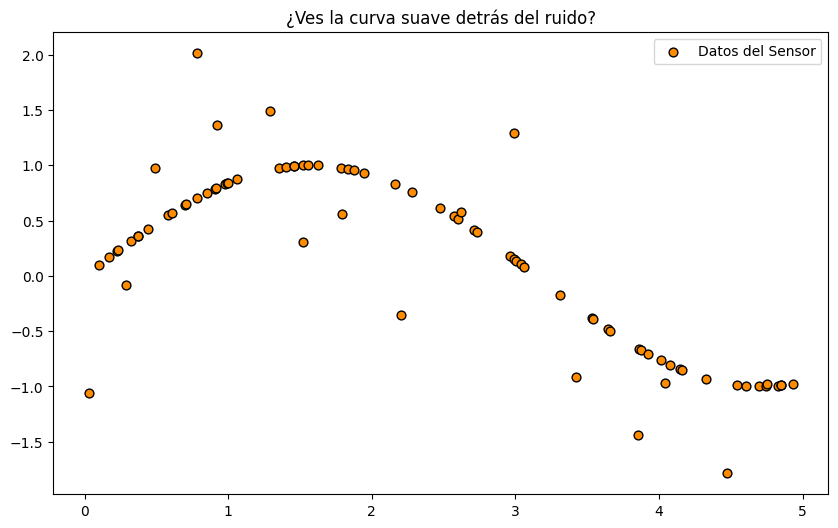

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generamos datos aleatorios
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0) # Valores de 0 a 5
y = np.sin(X).ravel() # La señal real (Seno)

# Añadimos ruido (interferencias)
y[::5] += 3 * (0.5 - np.random.rand(16))

# Visualizamos
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=40, edgecolor="black", c="darkorange", label="Datos del Sensor")
plt.title("¿Ves la curva suave detrás del ruido?")
plt.legend()
plt.show()

## 2. Los Dos Extremos

Vamos a entrenar dos modelos usando **DecisionTreeRegressor**:
1.  **El "Vago" (Underfitting):** Le limitamos la profundidad a 2 (`max_depth=2`). Es demasiado simple para entender una curva.
2.  **El "Memorión" (Overfitting):** Le dejamos profundidad infinita (`max_depth=None`). Memorizará cada punto de ruido.

In [5]:
from sklearn.tree import DecisionTreeRegressor

# MODELO 1: UNDERFITTING (Muy simple)
# Solo le dejamos hacer 2 preguntas (profundidad 2)
regr_1 = DecisionTreeRegressor(max_depth=2) # TODO: Pon un 2
regr_1.fit(X, y)

# MODELO 2: OVERFITTING (Muy complejo)
# Le dejamos crecer hasta el infinito (None)
regr_2 = DecisionTreeRegressor(max_depth=None) # TODO: Pon None
regr_2.fit(X, y)

print("Modelos entrenados.")

Modelos entrenados.


## 3. La Comparativa Visual

Para ver qué han aprendido, vamos a pedirles que predigan una línea suave continua de 0 a 5.

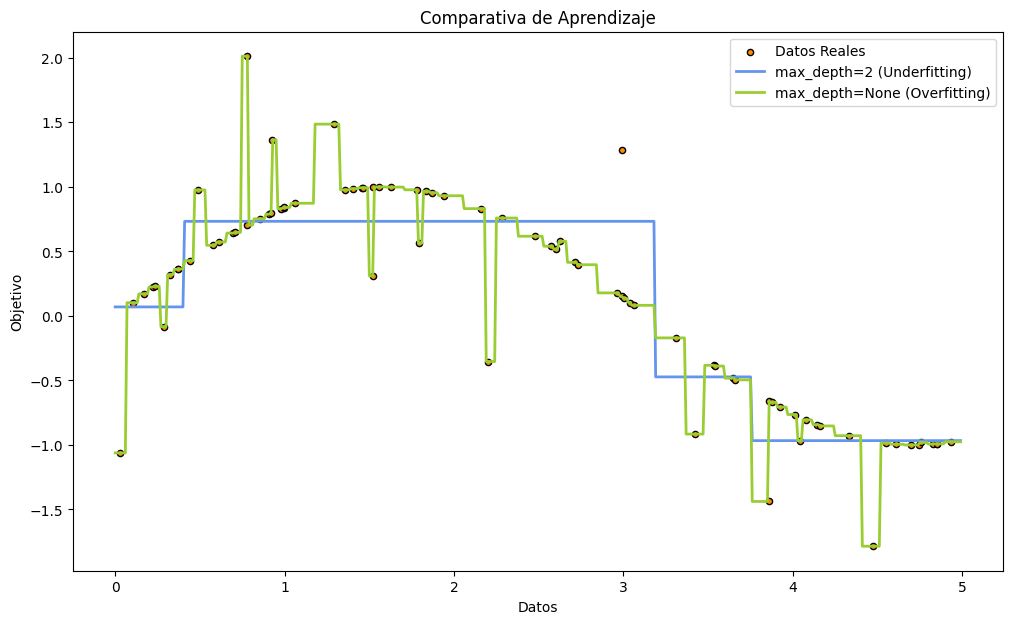

In [6]:
# Creamos datos de prueba (una línea continua) para pintar el dibujo
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

# Predecimos con ambos modelos
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

# DIBUJAR
plt.figure(figsize=(12, 7))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos Reales")

# Línea del Modelo Simple
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2 (Underfitting)", linewidth=2)

# Línea del Modelo Complejo
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=None (Overfitting)", linewidth=2)

plt.xlabel("Datos")
plt.ylabel("Objetivo")
plt.title("Comparativa de Aprendizaje")
plt.legend()
plt.show()

# REFLEXIÓN:
# - Mira la línea AZUL: Es demasiado rígida. No captura la curva.
# - Mira la línea VERDE: Es nerviosa. Sube y baja violentamente para tocar cada punto de ruido.
#
# NINGUNO ES BUENO. Necesitamos algo intermedio (ej. max_depth=5).

## 4. El "Sweet Spot" (Generalización)

Tu trabajo como Data Scientist es encontrar el equilibrio. Vamos a probar con `max_depth=5`.

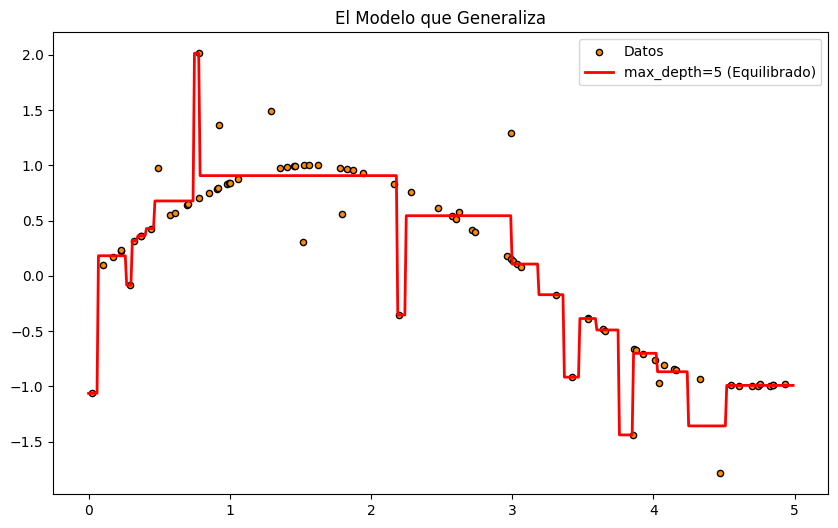

In [7]:
# MODELO 3: EQUILIBRADO
regr_3 = DecisionTreeRegressor(max_depth=5)
regr_3.fit(X, y)
y_3 = regr_3.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos")
plt.plot(X_test, y_3, color="red", label="max_depth=5 (Equilibrado)", linewidth=2)
plt.title("El Modelo que Generaliza")
plt.legend()
plt.show()

# Fíjate que captura la curva del seno pero ignora los picos más locos del ruido.